MobileNetV2 Training (Step-by-step)

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)


TensorFlow: 2.13.0


In [2]:
TRAIN_DIR = "../dataset/train"
VAL_DIR   = "../dataset/validation"
TEST_DIR  = "../dataset/test"

IMG_SIZE = 224
BATCH_SIZE = 8  # CPU-safe


Preprocessing for MobileNetV2 (CT + MobileNet preprocess_input)

In [3]:
import cv2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def mobilenet_preprocessing(img):
    img = img.astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    gray = cv2.GaussianBlur(gray, (3,3), 0)

    x = np.stack([gray, gray, gray], axis=-1).astype(np.float32)

    # MobileNetV2 expected preprocessing
    x = preprocess_input(x)  # scales to [-1, 1]

    return x


In [4]:
train_gen = ImageDataGenerator(
    preprocessing_function=mobilenet_preprocessing,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True
)

val_gen  = ImageDataGenerator(preprocessing_function=mobilenet_preprocessing)
test_gen = ImageDataGenerator(preprocessing_function=mobilenet_preprocessing)

train_data = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary"
)

val_data = val_gen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary"
)

test_data = test_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary",
    shuffle=False
)

print("Class indices:", train_data.class_indices)


Found 1843 images belonging to 2 classes.
Found 235 images belonging to 2 classes.
Found 437 images belonging to 2 classes.
Class indices: {'Normal': 0, 'Stroke': 1}


In [5]:
class_weights = {0: 0.8477460901563938, 1: 1.218915343915344}
class_weights


{0: 0.8477460901563938, 1: 1.218915343915344}

Cell 6 — Build MobileNetV2 Model (Frozen Backbone) 

In [6]:
base = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_tensor=Input(shape=(IMG_SIZE, IMG_SIZE, 3))
)

base.trainable = False  # phase-1

x = base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
out = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base.input, outputs=out)
model.summary()


9406464/9406464 [==============================] - 3s 0us/step
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 112, 112, 32)         864       ['input_1[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 112, 112, 32)         128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (N

In [7]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)


In [8]:
os.makedirs("../models", exist_ok=True)

callbacks = [
    ModelCheckpoint(
        "../models/mobilenetv2_best.h5",
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]


In [9]:
EPOCHS = 25

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/25
231/231 [==============================] - ETA: 0s - loss: 0.7514 - accuracy: 0.5334 - precision: 0.4441 - recall: 0.5463 - auc: 0.5472
Epoch 1: val_auc improved from -inf to 0.67532, saving model to ../models\mobilenetv2_best.h5


c:\Users\admin\Desktop\Brain_Stroke_Project\stroke_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


231/231 [==============================] - 60s 245ms/step - loss: 0.7514 - accuracy: 0.5334 - precision: 0.4441 - recall: 0.5463 - auc: 0.5472 - val_loss: 0.6662 - val_accuracy: 0.6170 - val_precision: 0.4492 - val_recall: 0.6795 - val_auc: 0.6753 - lr: 1.0000e-04
Epoch 2/25
231/231 [==============================] - ETA: 0s - loss: 0.6819 - accuracy: 0.5784 - precision: 0.4880 - recall: 0.5661 - auc: 0.6042
Epoch 2: val_auc improved from 0.67532 to 0.69541, saving model to ../models\mobilenetv2_best.h5
231/231 [==============================] - 61s 263ms/step - loss: 0.6819 - accuracy: 0.5784 - precision: 0.4880 - recall: 0.5661 - auc: 0.6042 - val_loss: 0.6721 - val_accuracy: 0.5830 - val_precision: 0.4265 - val_recall: 0.7436 - val_auc: 0.6954 - lr: 1.0000e-04
Epoch 3/25
231/231 [==============================] - ETA: 0s - loss: 0.6380 - accuracy: 0.6300 - precision: 0.5432 - recall: 0.6151 - auc: 0.6855
Epoch 3: val_auc improved from 0.69541 to 0.69606, saving model to ../models\mo

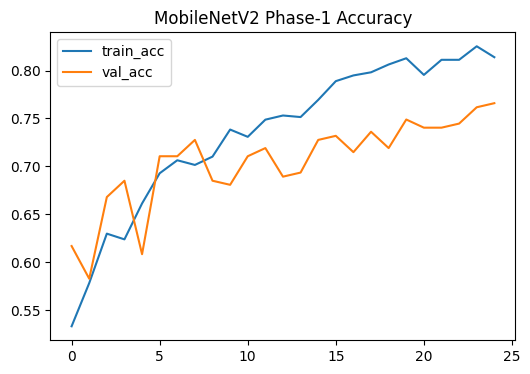

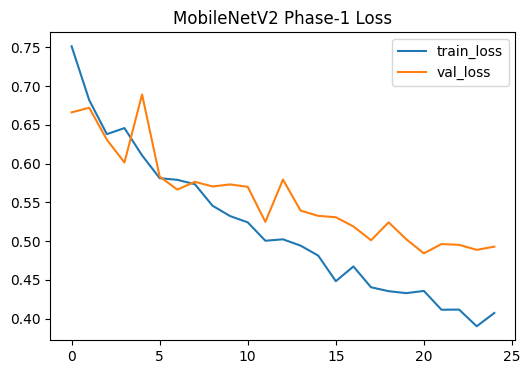

In [10]:
def plot_history(hist, title):
    h = hist.history

    plt.figure(figsize=(6,4))
    plt.plot(h["accuracy"], label="train_acc")
    plt.plot(h["val_accuracy"], label="val_acc")
    plt.title(f"{title} Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(6,4))
    plt.plot(h["loss"], label="train_loss")
    plt.plot(h["val_loss"], label="val_loss")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

plot_history(history1, "MobileNetV2 Phase-1")


In [11]:
test_metrics = model.evaluate(test_data, verbose=1)
print(dict(zip(model.metrics_names, test_metrics)))


55/55 [==============================] - 10s 181ms/step - loss: 0.4868 - accuracy: 0.7460 - precision: 0.5549 - recall: 0.7385 - auc: 0.8483
{'loss': 0.48682695627212524, 'accuracy': 0.7459954023361206, 'precision': 0.5549132823944092, 'recall': 0.7384615540504456, 'auc': 0.8483086824417114}


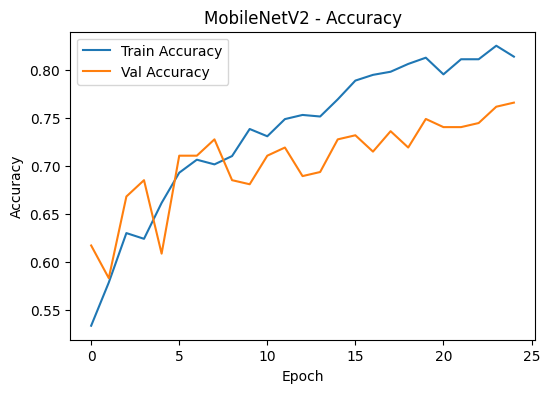

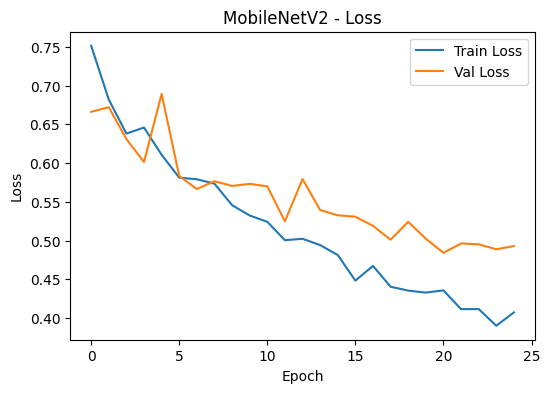

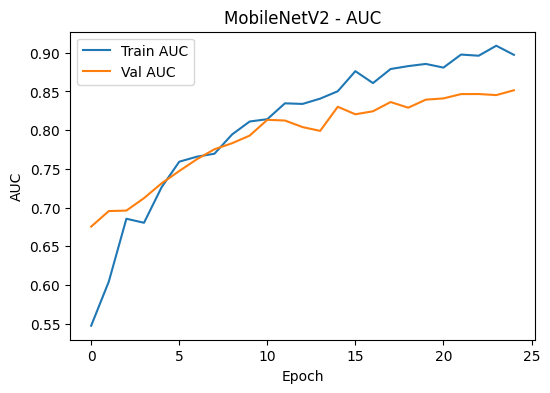

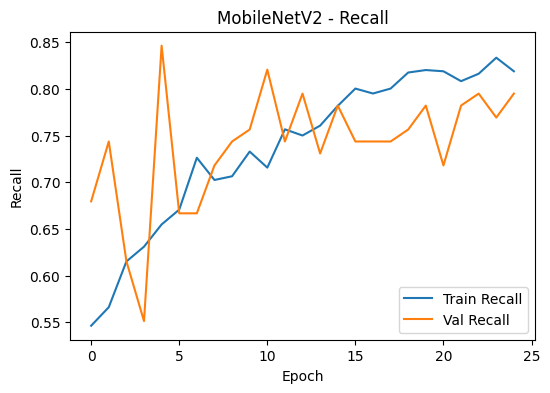

In [12]:
import matplotlib.pyplot as plt

def plot_history_metrics(history, title_prefix="MobileNetV2"):
    h = history.history
    
    # Accuracy
    plt.figure(figsize=(6,4))
    plt.plot(h["accuracy"], label="Train Accuracy")
    plt.plot(h["val_accuracy"], label="Val Accuracy")
    plt.title(f"{title_prefix} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    # Loss
    plt.figure(figsize=(6,4))
    plt.plot(h["loss"], label="Train Loss")
    plt.plot(h["val_loss"], label="Val Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # AUC
    plt.figure(figsize=(6,4))
    plt.plot(h["auc"], label="Train AUC")
    plt.plot(h["val_auc"], label="Val AUC")
    plt.title(f"{title_prefix} - AUC")
    plt.xlabel("Epoch")
    plt.ylabel("AUC")
    plt.legend()
    plt.show()

    # Recall
    plt.figure(figsize=(6,4))
    plt.plot(h["recall"], label="Train Recall")
    plt.plot(h["val_recall"], label="Val Recall")
    plt.title(f"{title_prefix} - Recall")
    plt.xlabel("Epoch")
    plt.ylabel("Recall")
    plt.legend()
    plt.show()

plot_history_metrics(history1, "MobileNetV2")


In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

test_data.reset()

y_prob = model.predict(test_data, verbose=1)  # probabilities
y_pred = (y_prob >= 0.5).astype(int).ravel() # predicted classes
y_true = test_data.classes                   # true classes

print(classification_report(y_true, y_pred, target_names=["Normal", "Stroke"]))


55/55 [==============================] - 9s 133ms/step
              precision    recall  f1-score   support

      Normal       0.87      0.75      0.81       307
      Stroke       0.55      0.74      0.63       130

    accuracy                           0.75       437
   macro avg       0.71      0.74      0.72       437
weighted avg       0.78      0.75      0.75       437



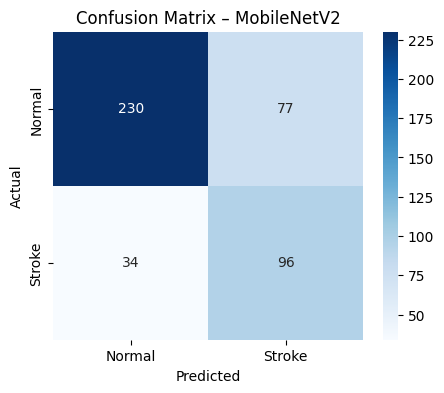

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal", "Stroke"],
    yticklabels=["Normal", "Stroke"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – MobileNetV2")
plt.show()


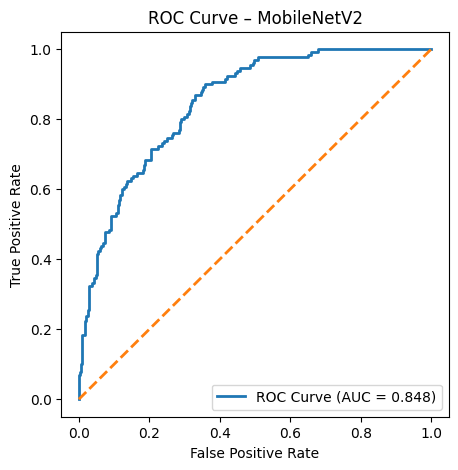

AUC: 0.8484339764470057


In [15]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – MobileNetV2")
plt.legend(loc="lower right")
plt.show()

print("AUC:", roc_auc)


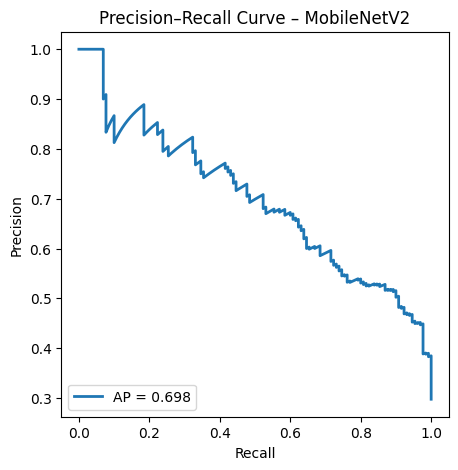

Average Precision (AP): 0.6982191209396512


In [16]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_true, y_prob)
ap = average_precision_score(y_true, y_prob)

plt.figure(figsize=(5,5))
plt.plot(recall, precision, lw=2, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – MobileNetV2")
plt.legend(loc="lower left")
plt.show()

print("Average Precision (AP):", ap)
